In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


비율로 자르기

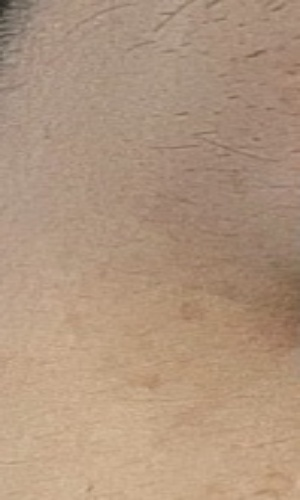

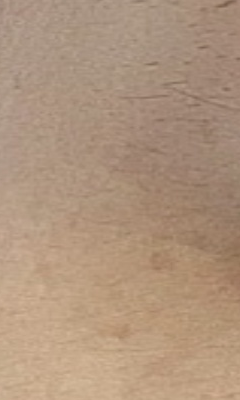

In [ ]:
import cv2
import os
from google.colab.patches import cv2_imshow # Import the alternative function

def center_crop(image, crop_ratio):
    """
    이미지의 중심 부분을 비율에 따라 자릅니다.

    Args:
    - image: 원본 이미지
    - crop_ratio: 자르고자 하는 비율 (0~1, 예: 0.5는 50%를 자름)

    Returns:
    - cropped_image: 중심 부분을 자른 이미지
    """
    height, width = image.shape[:2]
    crop_width = int(width * crop_ratio)
    crop_height = int(height * crop_ratio)

    start_x = width // 2 - crop_width // 2
    start_y = height // 2 - crop_height // 2

    cropped_image = image[start_y:start_y + crop_height, start_x:start_x + crop_width]
    return cropped_image

image = cv2.imread('/content/drive/MyDrive/Final_project/image_detect/Front_data/train/cropped/l_peroucular/0014_03_F.jpg_l_peroucular.jpg')
result_1 = center_crop(image, 1)
result_2 = center_crop(image, 0.7)

#자른 이미지 보기
cv2_imshow(result_1)
cv2_imshow(result_2) # Use cv2_imshow instead of cv2.imshow
 # Use cv2_imshow instead of cv2.imshow
# cv2.waitKey(0)  # These lines are not needed with cv2_imshow
# cv2.destroyAllWindows()

중심 자르기

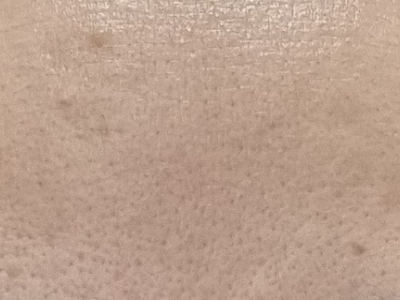

In [ ]:
import cv2
import os
from google.colab.patches import cv2_imshow # Import the alternative function
def resize_and_crop(image, target_size):
    """
    이미지의 크기를 변경하고, 특정 크기로 자릅니다.

    Args:
    - image: 원본 이미지
    - target_size: 자르고자 하는 목표 크기 (width, height)

    Returns:
    - cropped_image: 특정 크기로 자른 이미지
    """
    height, width = image.shape[:2]

    # 먼저 이미지를 target_size에 맞게 비율대로 리사이즈
    scale = max(target_size[0] / width, target_size[1] / height)
    resized_image = cv2.resize(image, (int(width * scale), int(height * scale)))

    # 중심 부분을 target_size 크기로 자르기
    start_x = resized_image.shape[1] // 2 - target_size[0] // 2
    start_y = resized_image.shape[0] // 2 - target_size[1] // 2

    cropped_image = resized_image[start_y:start_y + target_size[1], start_x:start_x + target_size[0]]
    return cropped_image

# 이미지 경로
image = cv2.imread('/content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Origin/train/forehead/0020_03_F.jpg_forehead.jpg')
result = resize_and_crop(image, (400, 300))
cv2_imshow(result)




In [ ]:
import cv2
import os
from google.colab.patches import cv2_imshow

def resize_and_crop(image, target_size):

    height, width = image.shape[:2]

    # 먼저 이미지를 target_size에 맞게 비율대로 리사이즈
    scale = max(target_size[0] / width, target_size[1] / height)
    resized_image = cv2.resize(image, (int(width * scale), int(height * scale)))

    # 중심 부분을 target_size 크기로 자르기
    start_x = resized_image.shape[1] // 2 - target_size[0] // 2
    start_y = resized_image.shape[0] // 2 - target_size[1] // 2

    cropped_image = resized_image[start_y:start_y + target_size[1], start_x:start_x + target_size[0]]
    return cropped_image

def process_images_in_folder(input_folder, output_folder, target_size):

    # 출력 폴더가 없으면 생성
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # 폴더 내 모든 파일 처리
    for filename in os.listdir(input_folder):
        if filename.endswith('.jpg'):
            # 이미지 읽기
            image_path = os.path.join(input_folder, filename)
            image = cv2.imread(image_path)

            if image is not None:
                # 이미지 리사이즈 및 자르기
                result = resize_and_crop(image, target_size)

                # 결과 이미지 저장
                output_path = os.path.join(output_folder, filename)
                cv2.imwrite(output_path, result)
                print(f'Saved: {output_path}')
            else:
                print(f'Failed to read image: {image_path}')

# 사용 예시
input_folder = '/content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Origin/val/forehead'
output_folder = '/content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/예진님/Resnet/Classification/forehead_wrinkle/image/val'
target_size = (400, 300)

process_images_in_folder(input_folder, output_folder, target_size)


Saved: /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/예진님/Resnet/Classification/forehead_wrinkle/image/val/0013_03_F.jpg_forehead.jpg
Saved: /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/예진님/Resnet/Classification/forehead_wrinkle/image/val/0004_03_F.jpg_forehead.jpg
Saved: /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/예진님/Resnet/Classification/forehead_wrinkle/image/val/0061_03_F.jpg_forehead.jpg
Saved: /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/예진님/Resnet/Classification/forehead_wrinkle/image/val/0001_03_F.jpg_forehead.jpg
Saved: /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/예진님/Resnet/Classification/forehead_wrinkle/image/val/0050_03_F.jpg_forehead.jpg
Saved: /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/예진님/Resnet/Classification/forehead_wrinkle/image/val/0021_03_F.jpg_forehead.jpg
Saved: /content/drive/MyDriv

테스트

In [ ]:
import os
import random
import cv2
import numpy as np

# crop_ratio : 자를 비율 (0~1) 1이 원본
def crop_image(image, crop_ratio):
    '''이미지를 동일한 비율로 자르는 함수 '''
    height, width = image.shape[:2]
    new_height, new_width = int(height * crop_ratio), int(width * crop_ratio)

    start_x = (width - new_width) // 2
    start_y = (height - new_height) // 2

    return image[start_y:start_y+new_height, start_x:start_x+new_width]

def augment_images(input_folder, output_folder, crop_ratio=0.8, percentage=0.3):
    """입력폴더(input_folder)에서 랜덤하게 선택하여 자르고, 새 폴더에 저장하는 함수 """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    image_files = [f for f in os.listdir(input_folder) if f.endswith('.jpg')]
    num_files_to_augment = int(len(image_files) * percentage) # 전체 파일개수에서 30% 계산
    files_to_augment = random.sample(image_files, num_files_to_augment) #랜덤으로 30%만큼 파일 뽑기

    for image_file in files_to_augment: #랜덤으로 뽑은 파일 이미지 읽기
        image_path = os.path.join(input_folder, image_file)
        image = cv2.imread(image_path)

        if image is None:
            continue

        cropped_image = crop_image(image, crop_ratio)
        output_path = os.path.join(output_folder, file_name)
        cv2.imwrite(output_path, cropped_image)

    print(f"{len(files_to_augment)} images were cropped and saved to {output_folder}")

#폴더
input_folder = "/content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Origin/train/forehead"
output_folder = "/content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Orientation/train/forehead/cut"

# 이미지 증강 수행 및 저장
augment_images(input_folder, output_folder, crop_ratio=0.8, percentage=0.3)



257 images were cropped and saved to /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Orientation/train/forehead/cut


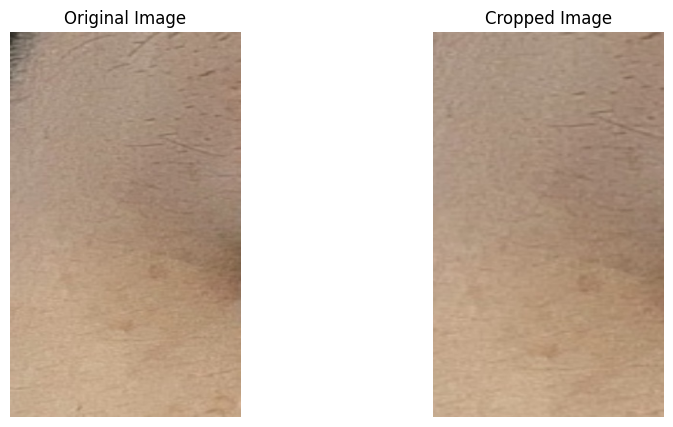

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# crop_ratio : 자를 비율 (0~1), 1이 원본 크기
def crop_image(image, crop_ratio):
    '''이미지를 동일한 비율로 자르는 함수'''
    height, width = image.shape[:2]
    new_height, new_width = int(height * crop_ratio), int(width * crop_ratio)

    start_x = (width - new_width) // 2
    start_y = (height - new_height) // 2

    return image[start_y:start_y+new_height, start_x:start_x+new_width]

def augment_and_show_image(image_path, crop_ratio=0.8):
    """이미지 1개를 받아 자르고, 결과 이미지를 보여주는 함수"""
    image = cv2.imread(image_path)

    if image is None:
        print("이미지를 불러올 수 없습니다.")
        return

    cropped_image = crop_image(image, crop_ratio)

    # 원본 이미지와 자른 이미지를 나란히 보여주기
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Cropped Image')
    axes[1].axis('off')

    plt.show()

# 이미지 경로 예시
image_path = "/content/drive/MyDrive/Final_project/image_detect/Front_data/train/cropped/l_peroucular/0014_03_F.jpg_l_peroucular.jpg"

# 이미지 증강 및 결과 이미지 표시
augment_and_show_image(image_path, crop_ratio=0.8)


- 이미지 원본이미지 80% 자르기
- 사이즈 동일하게 저장

In [ ]:
import os
import random
import cv2
import numpy as np

# crop_ratio : 자를 비율 (0~1) 1이 원본
def crop_image(image, crop_ratio):
    '''이미지를 동일한 비율로 자르는 함수 '''
    height, width = image.shape[:2]
    new_height, new_width = int(height * crop_ratio), int(width * crop_ratio)

    start_x = (width - new_width) // 2
    start_y = (height - new_height) // 2

    return image[start_y:start_y+new_height, start_x:start_x+new_width]

#####################################################################################################################
#사이즈 맞춰서 저장
def resize_image(image, target_size):
    '''이미지를 주어진 크기로 리사이즈하는 함수'''
    return cv2.resize(image, target_size)

#####################################################################################################################

def augment_images(input_folders, output_folder, crop_ratio=0.8, percentage=0.3, target_size=(224, 224)):
    """입력폴더(input_folder)에서 랜덤하게 선택하여 자르고, 새 폴더에 저장하는 함수 """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    image_files = []
    for folder in input_folders:
        image_files += [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.jpg')]

    num_files_to_augment = int(len(image_files) * percentage) # 전체 파일개수에서 30% 계산
    files_to_augment = random.sample(image_files, num_files_to_augment) #랜덤으로 30%만큼 파일 뽑기

    for image_file in files_to_augment: #랜덤으로 뽑은 파일 이미지 읽기
        image = cv2.imread(image_file)

        if image is None:
            continue

        cropped_image = crop_image(image, crop_ratio) # 0.8% 자르고
        resized_image = resize_image(cropped_image, target_size) # 사이즈 지정
        output_path = os.path.join(output_folder, os.path.basename(image_file))
        cv2.imwrite(output_path, resized_image) # 저장

        print(f"Image saved: {output_path}")

    print(f"{len(files_to_augment)} images were cropped and saved to {output_folder}")

######################################################################################################################

# 기본 경로 및 부위별 폴더 설정
input_folders = [
                    "/content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Orientation/val/glabellus/glabellus_origin",
                     "/content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Orientation/val/glabellus/smart_pad"]

output_folder = "/content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Orientation/val/glabellus/cut"
target_size = (300, 350)

#이마 (700, 250) / 볼 (400, 560) / 눈가 (160, 350) / 미간(300, 350)
# 이미지 증강 수행 및 저장
augment_images(input_folders, output_folder, crop_ratio=0.8, percentage=0.3, target_size=target_size)

Image saved: /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Orientation/val/glabellus/cut/0944_02_F_glabellus_sp.jpg
Image saved: /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Orientation/val/glabellus/cut/0951_03_F.jpg_glabellus.jpg
Image saved: /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Orientation/val/glabellus/cut/0262_02_F_glabellus_sp.jpg
Image saved: /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Orientation/val/glabellus/cut/0944_03_F.jpg_glabellus.jpg
Image saved: /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Orientation/val/glabellus/cut/0569_03_F.jpg_glabellus.jpg
Image saved: /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Orientation/val/glabellus/cut/0450_03_F.jpg_glabellus.jpg
Image saved: /content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/im